# Goal Conditioning Testbed — Levels 0 and 1

**Purpose**: Empirical evidence that a pedestrian goal-endpoint is an informative signal *beyond* what the ego trajectory already explains, and that the VAE latent space encodes goal structure.

| Level | Question | Requires |
|-------|----------|----------|
| **L0** | Is goal an independent signal beyond ego? | No model — pure data analysis |
| **L1** | Does the VAE latent encode goal? | Both VAE checkpoints |
| **Optional** | Does the ego encoder predict goal better than raw trajectory? | Ego encoder checkpoint |

**Decision criteria**:
- L0 R² < 0.3 and high within-group variance → proceed with goal conditioning
- L1 VAE latents cluster by goal → conditioning via latent injection is architecturally sound
- AD-only VAE higher R² → use AD-only VAE as the base

In [1]:
# ── Uncomment to install if needed ──────────────────────────────
!pip install scikit-learn tqdm matplotlib
# ────────────────────────────────────────────────────────────────
import os
import sys
import json
import glob
from collections import OrderedDict

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

import warnings
warnings.filterwarnings('ignore')

# Repo root must be on sys.path so mld.* imports work
REPO_ROOT = os.path.abspath('.')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print(f'Repo root : {REPO_ROOT}')
print(f'PyTorch   : {torch.__version__}')
print(f'CUDA      : {torch.cuda.is_available()}')

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


/home/mohan/miniconda3/envs/mld/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root : /home/mohan/Documents/erik/codebases/motion-latent-diffusion
PyTorch   : 1.12.1
CUDA      : True


In [2]:
# ================================================================
# CONFIGURATION  —  edit paths here if anything has moved
# ================================================================
NAS_BASE = '/home/mohan/nas_drive/methods/diffusion_gen'

DATA_ROOTS = [
    f'{NAS_BASE}/data/diffusion/ava/train',
    f'{NAS_BASE}/data/diffusion/nuscenes/train',
    f'{NAS_BASE}/data/diffusion/waymo/train',
]

# VAE checkpoint folders
VAE_ROOT       = f'{NAS_BASE}/models/vae'
VAE_ALL_FOLDER = '1222_PELearn_VAE_MEncDec49_MdiffEnc49_bs64_clip_uncond75_01'
VAE_AD_FOLDER  = 'vae_ava_nuscenes_waymo'

# Matched mean/std for each VAE
MEAN_STD_ALL = f'{NAS_BASE}/data/vae/mean_std_txt/ava_human_nuscenes_waymo'
MEAN_STD_AD  = f'{NAS_BASE}/data/vae/mean_std_txt/ava_nuscenes_waymo'

# Ego encoder folder (4 sub-folders, one per variant)
EGO_ENCODER_ROOT = f'{NAS_BASE}/models/ego_encoder'
EGO_SCALE        = 50.0   # same scale used during training

N_SAMPLES = 300
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
# ── Helper functions ─────────────────────────────────────────────

def find_latest_ckpt(folder_path):
    """Return the checkpoint with the highest epoch number in <folder>/checkpoints/."""
    ckpt_dir = os.path.join(folder_path, 'checkpoints')
    ckpts = glob.glob(os.path.join(ckpt_dir, 'epoch=*.ckpt'))
    if not ckpts:
        raise FileNotFoundError(f'No epoch=*.ckpt found in {ckpt_dir}')
    def _epoch(p):
        try:
            return int(os.path.basename(p).split('=')[1].split('.')[0])
        except Exception:
            return -1
    return sorted(ckpts, key=_epoch)[-1]


def classify_ego_dir(ego_final_xz):
    """Bin ego final position (x, z) into 4 directional quadrants."""
    x, z = float(ego_final_xz[0]), float(ego_final_xz[1])
    if abs(x) >= abs(z):
        return 'right' if x >= 0 else 'left'
    else:
        return 'front' if z >= 0 else 'back'


def extract_endpoint(motion_feats_raw):
    """
    Extract pedestrian endpoint from raw (unnormalized) 263-dim motion features.
    Uses recover_from_ric to get joint positions, then returns the pelvis (joint 0)
    position at the last frame in the XZ plane.
    """
    from mld.data.humanml.scripts.motion_process import recover_from_ric
    t = torch.from_numpy(motion_feats_raw).float().unsqueeze(0)  # (1, T, 263)
    with torch.no_grad():
        joints = recover_from_ric(t, 22)   # (1, T, 22, 3)
    joints = joints.squeeze(0).numpy()     # (T, 22, 3)
    return joints[-1, 0, [0, 2]].copy()   # (x, z) at last frame, pelvis joint


DIR_ORDER  = ['front', 'back', 'left', 'right']
DIR_COLORS = {'front': '#e41a1c', 'back': '#377eb8', 'left': '#4daf4a', 'right': '#ff7f00'}

In [4]:
# ── Load N samples from JSON files ──────────────────────────────
print(f'Loading up to {N_SAMPLES} samples from {len(DATA_ROOTS)} roots ...')

samples = []
for root in DATA_ROOTS:
    if len(samples) >= N_SAMPLES:
        break
    json_files = sorted(glob.glob(os.path.join(root, '*.json')))
    print(f'  {os.path.basename(os.path.dirname(root))}: {len(json_files)} files')
    for fpath in json_files:
        if len(samples) >= N_SAMPLES:
            break
        try:
            with open(fpath) as f:
                data = json.load(f)

            # Ego trajectory: take x and z columns only
            ego_xyz = np.array(data['ego_in_ped_frame'], dtype=np.float32)  # (T_ego, 3)
            ego     = ego_xyz[:, [0, 2]]                                     # (T_ego, 2)

            # Raw (unnormalized) motion features
            motion_feats = np.array(data['vectors_263'], dtype=np.float32)   # (T, 263)
            T_motion = motion_feats.shape[0]
            T_ego    = ego.shape[0]

            if T_motion < 10 or T_ego < 2 or motion_feats.shape[1] != 263:
                continue

            endpoint  = extract_endpoint(motion_feats)  # (x, z)
            ego_final = ego[-1]                          # (x, z)
            ego_dir   = classify_ego_dir(ego_final)

            samples.append({
                'ego':          ego,
                'motion_feats': motion_feats,
                'endpoint':     endpoint,
                'ego_final':    ego_final,
                'ego_dir':      ego_dir,
                'length':       T_motion,
            })
        except Exception:
            pass

print(f'\nLoaded {len(samples)} samples.')

Loading up to 300 samples from 3 roots ...
  ava: 27 files
  nuscenes: 3611 files

Loaded 300 samples.


In [5]:
# ── Aggregate arrays ─────────────────────────────────────────────
endpoints  = np.array([s['endpoint']  for s in samples], dtype=np.float32)  # (N, 2)
ego_finals = np.array([s['ego_final'] for s in samples], dtype=np.float32)  # (N, 2)
ego_dirs   = [s['ego_dir'] for s in samples]
lengths    = [s['length']  for s in samples]

dir_counts = {d: sum(1 for s in ego_dirs if s == d) for d in DIR_ORDER}
print('Ego direction distribution:', dir_counts)
print(f'Endpoint X: [{endpoints[:,0].min():.2f}, {endpoints[:,0].max():.2f}]  '
      f'Z: [{endpoints[:,1].min():.2f}, {endpoints[:,1].max():.2f}]')
print(f'Ego final X: [{ego_finals[:,0].min():.2f}, {ego_finals[:,0].max():.2f}]  '
      f'Z: [{ego_finals[:,1].min():.2f}, {ego_finals[:,1].max():.2f}]')
print(f'Motion length — mean: {np.mean(lengths):.1f},  range: [{min(lengths)}, {max(lengths)}]')

Ego direction distribution: {'front': 89, 'back': 83, 'left': 65, 'right': 63}
Endpoint X: [-14.31, 18.76]  Z: [-5.76, 25.86]
Ego final X: [-47.90, 48.53]  Z: [-61.37, 65.93]
Motion length — mean: 165.0,  range: [13, 485]


---
## Level 0: Is Goal an Informative Signal Beyond Ego?

**No model required.** Pure data analysis.

- **Analysis A** — Group endpoints by ego direction quadrant → measure within-group variance  
  *High variance → ego direction ≠ goal → goal carries independent information*
- **Analysis B** — Linear regression `ego_final (2D) → endpoint (2D)` → report R²  
  *Low R² → ego weakly predicts endpoint → strong motivation for explicit goal conditioning*

In [6]:
# ── Analysis A: per-group endpoint variance ──────────────────────
group_endpoints = {}
group_variance  = {}
for d in DIR_ORDER:
    mask = np.array([s == d for s in ego_dirs])
    if mask.sum() < 2:
        continue
    pts = endpoints[mask]
    group_endpoints[d] = pts
    group_variance[d]  = float(np.trace(np.cov(pts.T)))

total_variance = float(np.trace(np.cov(endpoints.T)))

print('=== Analysis A: Within-Group Endpoint Variance ===')
print(f'Total endpoint variance (trace of cov): {total_variance:.4f}')
for d in DIR_ORDER:
    if d in group_variance:
        pct = 100 * group_variance[d] / total_variance
        n   = len(group_endpoints[d])
        print(f'  {d:8s}: variance = {group_variance[d]:.4f}  ({pct:.1f}% of total)  n={n}')
print()
print('High within-group variance means ego direction does not determine goal.')
print('That is the signal we need: goal carries independent information beyond ego.')

=== Analysis A: Within-Group Endpoint Variance ===
Total endpoint variance (trace of cov): 51.0104
  front   : variance = 71.1033  (139.4% of total)  n=89
  back    : variance = 16.8349  (33.0% of total)  n=83
  left    : variance = 43.3830  (85.0% of total)  n=65
  right   : variance = 46.4817  (91.1% of total)  n=63

High within-group variance means ego direction does not determine goal.
That is the signal we need: goal carries independent information beyond ego.


In [7]:
# ── Analysis B: linear regression ego_final → endpoint ──────────
reg_l0         = LinearRegression().fit(ego_finals, endpoints)
endpoints_pred = reg_l0.predict(ego_finals)

r2_l0   = r2_score(endpoints,       endpoints_pred,       multioutput='uniform_average')
r2_l0_x = r2_score(endpoints[:, 0], endpoints_pred[:, 0])
r2_l0_z = r2_score(endpoints[:, 1], endpoints_pred[:, 1])
residuals = endpoints - endpoints_pred
resid_var = float(np.trace(np.cov(residuals.T)))

print('=== Analysis B: Linear Regression  ego_final (2D) → endpoint ===')
print(f'  R² (average) = {r2_l0:.4f}')
print(f'  R² (X dim)   = {r2_l0_x:.4f}')
print(f'  R² (Z dim)   = {r2_l0_z:.4f}')
print(f'  Residual var = {resid_var:.4f}  ({100*resid_var/total_variance:.1f}% of total endpoint var)')
print()
if r2_l0 < 0.2:
    print('R² < 0.2 — ego final position is a WEAK predictor. Strong case for goal conditioning.')
elif r2_l0 < 0.4:
    print('R² 0.2-0.4 — ego explains some variance; goal still adds meaningful information.')
elif r2_l0 < 0.6:
    print('R² 0.4-0.6 — moderate correlation; goal partly overlaps ego.')
else:
    print('R² > 0.6 — ego strongly predicts goal; conditioning value may be limited.')

=== Analysis B: Linear Regression  ego_final (2D) → endpoint ===
  R² (average) = 0.0462
  R² (X dim)   = 0.0013
  R² (Z dim)   = 0.0911
  Residual var = 47.2800  (92.7% of total endpoint var)

R² < 0.2 — ego final position is a WEAK predictor. Strong case for goal conditioning.


Saved: testbed_L0_endpoint_scatter.png


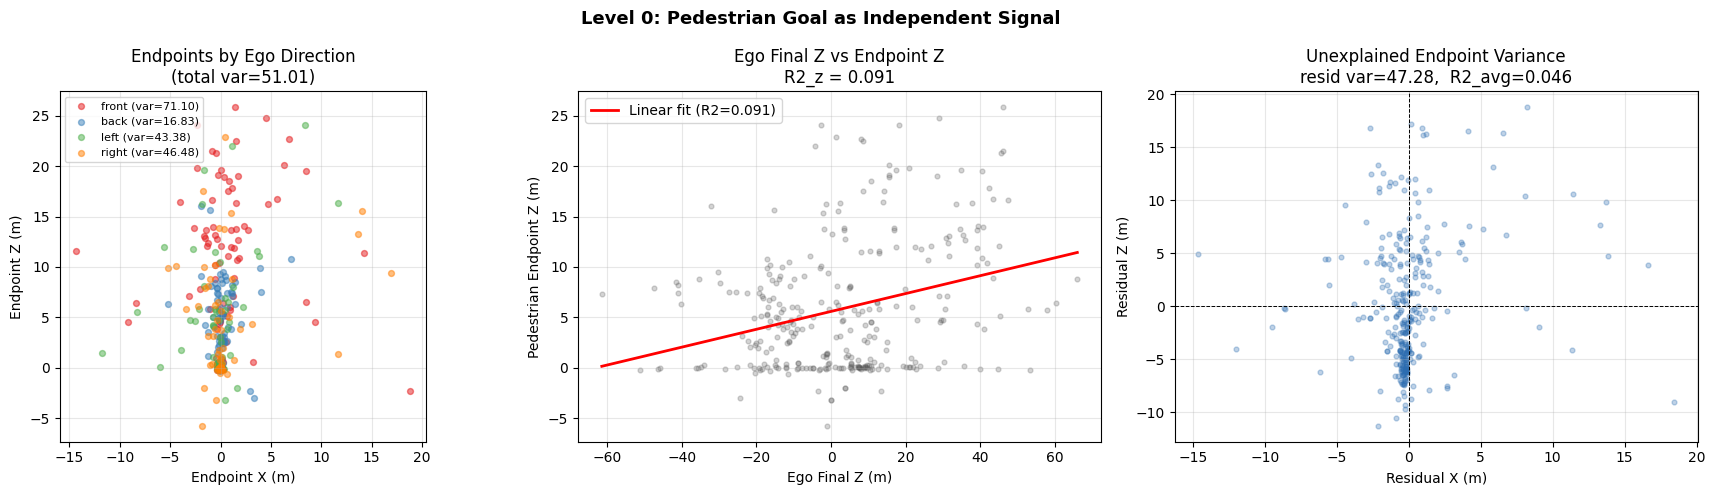

In [8]:
# ── Level 0 figure: 3 panels ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Level 0: Pedestrian Goal as Independent Signal', fontsize=13, fontweight='bold')

# Panel 1: scatter all endpoints, colored by ego direction
ax = axes[0]
for d in DIR_ORDER:
    mask = np.array([s == d for s in ego_dirs])
    if mask.sum() == 0:
        continue
    v = group_variance.get(d, 0)
    ax.scatter(endpoints[mask, 0], endpoints[mask, 1],
               c=DIR_COLORS[d], alpha=0.5, s=18, label=f'{d} (var={v:.2f})')
ax.set_xlabel('Endpoint X (m)'); ax.set_ylabel('Endpoint Z (m)')
ax.set_title(f'Endpoints by Ego Direction\n(total var={total_variance:.2f})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# Panel 2: ego_final Z vs endpoint Z + regression line
ax = axes[1]
ax.scatter(ego_finals[:, 1], endpoints[:, 1], alpha=0.25, s=12, c='#555555')
zl = np.linspace(ego_finals[:, 1].min(), ego_finals[:, 1].max(), 60)
zp = reg_l0.predict(np.column_stack([np.zeros(60), zl]))[:, 1]
ax.plot(zl, zp, 'r-', linewidth=2, label=f'Linear fit (R2={r2_l0_z:.3f})')
ax.set_xlabel('Ego Final Z (m)'); ax.set_ylabel('Pedestrian Endpoint Z (m)')
ax.set_title(f'Ego Final Z vs Endpoint Z\nR2_z = {r2_l0_z:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel 3: residual scatter (unexplained variance)
ax = axes[2]
ax.scatter(residuals[:, 0], residuals[:, 1], alpha=0.3, s=12, c='#2b6cb0')
ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
ax.axvline(0, color='k', linewidth=0.7, linestyle='--')
ax.set_xlabel('Residual X (m)'); ax.set_ylabel('Residual Z (m)')
ax.set_title(f'Unexplained Endpoint Variance\nresid var={resid_var:.2f},  R2_avg={r2_l0:.3f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('testbed_L0_endpoint_scatter.png', dpi=150, bbox_inches='tight')
print('Saved: testbed_L0_endpoint_scatter.png')
plt.show()

---
## Level 1: Does the VAE Latent Encode Goal?

**Question**: Do motions with similar endpoints cluster together in the VAE latent space?

If yes — the latent space has goal-structured geometry → the downstream diffusion model has meaningful structure to learn goal conditioning over.

Run with **both VAEs** and compare:
- `ALL-data VAE`: trained on HumanML3D + AVA + NuScenes + Waymo
- `AD-only VAE`: trained on AVA + NuScenes + Waymo only

**Method**: encode all N motions (posterior mean, deterministic) → PCA(2) scatter → linear regression `z(256D) → endpoint` → R²

In [9]:
# ── VAE build / load utilities ───────────────────────────────────
from omegaconf import OmegaConf
from mld.config import get_module_config, instantiate_from_config


def build_vae_from_config():
    """Instantiate the MLD VAE architecture from the standard config files."""
    cfg_base   = OmegaConf.load('./configs/base.yaml')
    cfg_exp    = OmegaConf.merge(cfg_base, OmegaConf.load('./configs/config_ego_motion_vae.yaml'))
    cfg_model  = get_module_config(cfg_exp.model, cfg_exp.model.target)
    cfg_assets = OmegaConf.load('./configs/assets.yaml')
    cfg        = OmegaConf.merge(cfg_exp, cfg_model, cfg_assets)
    return instantiate_from_config(cfg.model.motion_vae)


def load_vae_ckpt(vae, ckpt_path):
    """Load VAE weights from a Lightning checkpoint (extracts vae.* keys)."""
    state = torch.load(ckpt_path, map_location='cpu')
    if 'state_dict' in state:
        state = state['state_dict']
    vae_dict = OrderedDict(
        (k.replace('vae.', '', 1), v)
        for k, v in state.items() if k.startswith('vae.')
    )
    if not vae_dict:
        vae.load_state_dict(state, strict=True)
        print(f'  Loaded standalone VAE  ({os.path.basename(ckpt_path)})')
    else:
        vae.load_state_dict(vae_dict, strict=True)
        print(f'  Loaded {len(vae_dict)} params from {os.path.basename(ckpt_path)}')
    # Set inference mode (equivalent to .eval() but avoids the eval() name)
    vae.train(False)
    return vae


@torch.no_grad()
def encode_all(vae, samples, mean, std, device=DEVICE):
    """
    Encode all motions through the VAE using the posterior mean (deterministic).
    Returns (N, 256) numpy array.
    """
    zs = []
    for s in tqdm(samples, desc='VAE encode'):
        feats_norm = (s['motion_feats'] - mean) / (std + 1e-8)
        x = torch.from_numpy(feats_norm).float().unsqueeze(0).to(device)  # (1, T, 263)
        _, dist = vae.encode(x, [s['length']])
        # dist is torch.distributions.Normal; dist.mean is the posterior mean (1, 1, 256)
        zs.append(dist.mean.squeeze().cpu().numpy())  # (256,)
    return np.stack(zs)  # (N, 256)

In [10]:
# ── Load mean/std and build + load both VAEs ─────────────────────
mean_all = np.load(os.path.join(MEAN_STD_ALL, 'Mean.npy'))
std_all  = np.load(os.path.join(MEAN_STD_ALL, 'Std.npy'))
mean_ad  = np.load(os.path.join(MEAN_STD_AD,  'Mean.npy'))
std_ad   = np.load(os.path.join(MEAN_STD_AD,  'Std.npy'))
print(f'Stats shapes — ALL: {mean_all.shape},  AD: {mean_ad.shape}')

ckpt_all = find_latest_ckpt(os.path.join(VAE_ROOT, VAE_ALL_FOLDER))
ckpt_ad  = find_latest_ckpt(os.path.join(VAE_ROOT, VAE_AD_FOLDER))
print(f'Checkpoints:')
print(f'  ALL-data : {ckpt_all}')
print(f'  AD-only  : {ckpt_ad}')

print('\nBuilding ALL-data VAE ...')
vae_all = build_vae_from_config()
vae_all = load_vae_ckpt(vae_all, ckpt_all)
vae_all = vae_all.to(DEVICE)

print('Building AD-only VAE ...')
vae_ad  = build_vae_from_config()
vae_ad  = load_vae_ckpt(vae_ad, ckpt_ad)
vae_ad  = vae_ad.to(DEVICE)

print('\nEncoding with ALL-data VAE ...')
z_all = encode_all(vae_all, samples, mean_all, std_all)

print('Encoding with AD-only VAE ...')
z_ad  = encode_all(vae_ad,  samples, mean_ad,  std_ad)

print(f'\nLatent shapes — z_all: {z_all.shape},  z_ad: {z_ad.shape}')

Stats shapes — ALL: (263,),  AD: (263,)
Checkpoints:
  ALL-data : /home/mohan/nas_drive/methods/diffusion_gen/models/vae/1222_PELearn_VAE_MEncDec49_MdiffEnc49_bs64_clip_uncond75_01/checkpoints/epoch=5999.ckpt
  AD-only  : /home/mohan/nas_drive/methods/diffusion_gen/models/vae/vae_ava_nuscenes_waymo/checkpoints/epoch=6999.ckpt

Building ALL-data VAE ...
  Loaded 297 params from epoch=5999.ckpt
Building AD-only VAE ...
  Loaded 297 params from epoch=6999.ckpt

Encoding with ALL-data VAE ...


VAE encode: 100%|██████████| 300/300 [00:01<00:00, 269.17it/s]


Encoding with AD-only VAE ...


VAE encode: 100%|██████████| 300/300 [00:00<00:00, 476.43it/s]


Latent shapes — z_all: (300, 256),  z_ad: (300, 256)


Saved: testbed_L1_all_data_vae_pca.png


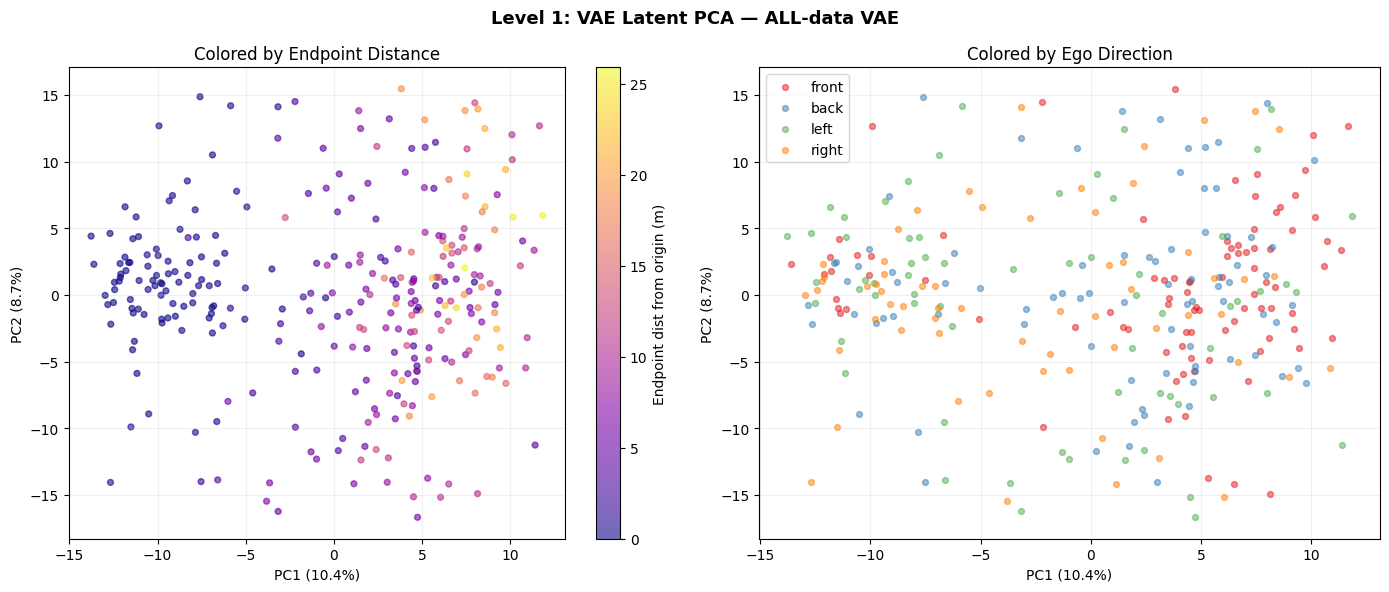

Saved: testbed_L1_ad_only_vae_pca.png


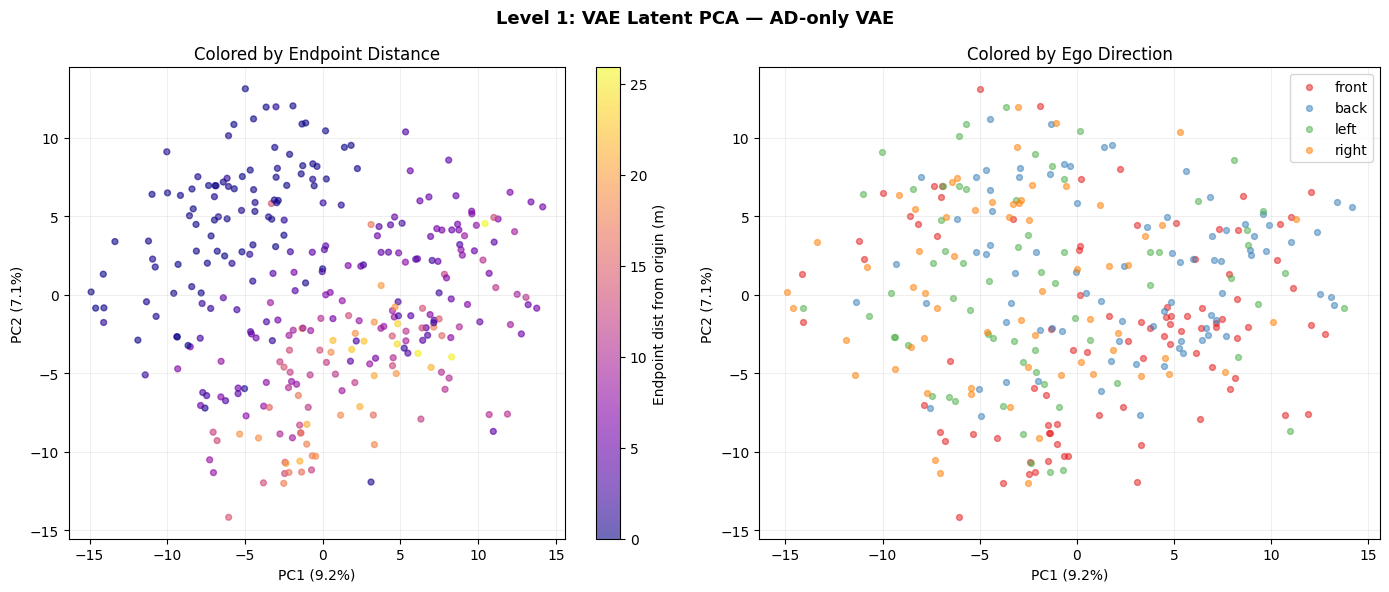

In [11]:
# ── PCA scatter plots ────────────────────────────────────────────
endpoint_dist = np.linalg.norm(endpoints, axis=1)  # scalar — continuous colormap

pca_all  = PCA(n_components=2).fit(z_all)
pca_ad   = PCA(n_components=2).fit(z_ad)
z_all_2d = pca_all.transform(z_all)
z_ad_2d  = pca_ad.transform(z_ad)


def pca_scatter_figure(z_2d, pca_obj, tag, out_fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Level 1: VAE Latent PCA — {tag}', fontsize=13, fontweight='bold')

    vr = pca_obj.explained_variance_ratio_ * 100
    xl = f'PC1 ({vr[0]:.1f}%)'
    yl = f'PC2 ({vr[1]:.1f}%)'

    # Left: colored by endpoint distance (continuous)
    sc = axes[0].scatter(z_2d[:, 0], z_2d[:, 1],
                         c=endpoint_dist, cmap='plasma', alpha=0.6, s=18)
    plt.colorbar(sc, ax=axes[0], label='Endpoint dist from origin (m)')
    axes[0].set_xlabel(xl); axes[0].set_ylabel(yl)
    axes[0].set_title('Colored by Endpoint Distance')
    axes[0].grid(True, alpha=0.2)

    # Right: colored by ego direction (categorical)
    for d in DIR_ORDER:
        mask = np.array([s == d for s in ego_dirs])
        if mask.sum() == 0:
            continue
        axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1],
                        c=DIR_COLORS[d], alpha=0.5, s=18, label=d)
    axes[1].set_xlabel(xl); axes[1].set_ylabel(yl)
    axes[1].set_title('Colored by Ego Direction')
    axes[1].legend(); axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(out_fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fname}')
    plt.show()


pca_scatter_figure(z_all_2d, pca_all, 'ALL-data VAE', 'testbed_L1_all_data_vae_pca.png')
pca_scatter_figure(z_ad_2d,  pca_ad,  'AD-only VAE',  'testbed_L1_ad_only_vae_pca.png')

In [12]:
# ── Linear regression: z(256D) → endpoint ────────────────────────
def latent_regression(z, targets, tag):
    reg  = LinearRegression().fit(z, targets)
    pred = reg.predict(z)
    r2_avg = r2_score(targets,       pred,       multioutput='uniform_average')
    r2_x   = r2_score(targets[:, 0], pred[:, 0])
    r2_z   = r2_score(targets[:, 1], pred[:, 1])
    print(f'  [{tag}]  R2_avg={r2_avg:.4f}  R2_x={r2_x:.4f}  R2_z={r2_z:.4f}')
    return r2_avg, r2_x, r2_z


print('=== Level 1: Linear Regression  z(256D) → endpoint ===')
r2_all_avg, r2_all_x, r2_all_z = latent_regression(z_all, endpoints, 'ALL-data VAE latent')
r2_ad_avg,  r2_ad_x,  r2_ad_z  = latent_regression(z_ad,  endpoints, 'AD-only  VAE latent')

print(f'\n[Baseline from L0]  ego_final(2D) → endpoint  R2_avg={r2_l0:.4f}')
print()
if max(r2_all_avg, r2_ad_avg) > r2_l0:
    print('VAE latent explains MORE endpoint variance than raw ego final position.')
    print('Latent space has goal structure — conditioning via latent injection is viable.')
else:
    print('VAE latent R2 <= ego_final R2.')
    print('VAE may not encode goal well; investigate before proceeding.')

if r2_ad_avg > r2_all_avg:
    print('\nAD-only VAE shows HIGHER goal R2 — cleaner goal structure (no HumanML3D noise).')
else:
    print('\nALL-data VAE shows equal/higher goal R2 — worth investigating.')

=== Level 1: Linear Regression  z(256D) → endpoint ===
  [ALL-data VAE latent]  R2_avg=0.9464  R2_x=0.9190  R2_z=0.9738
  [AD-only  VAE latent]  R2_avg=0.9216  R2_x=0.8881  R2_z=0.9551

[Baseline from L0]  ego_final(2D) → endpoint  R2_avg=0.0462

VAE latent explains MORE endpoint variance than raw ego final position.
Latent space has goal structure — conditioning via latent injection is viable.

ALL-data VAE shows equal/higher goal R2 — worth investigating.


---
## Optional: Ego Encoder Probe

**Question**: Does the ego encoder's 256D embedding predict pedestrian endpoint *better* than the raw 2D ego final position?

- Ego embedding R² > ego_final R² → encoder extracts richer goal-predictive features than position alone
- Compare both to VAE latent R² from Level 1 → which signal is most goal-informative?

Skipped gracefully if no checkpoint is found.

In [13]:
# ── Load ALL 4 ego encoder variants ──────────────────────────────
import glob
import os
from mld.models.architectures.ego_encoder import EgoEncoderPooled

def _load_ego_encoder(ckpt_path, device):
    state = torch.load(ckpt_path, map_location='cpu')
    if isinstance(state, dict):
        if 'ego_encoder' in state:
            state = state['ego_encoder']   # pretrain_ego_encoder.py format
        elif 'state_dict' in state:
            state = state['state_dict']
        elif 'model' in state:
            state = state['model']
    enc = EgoEncoderPooled(input_dim=2, latent_dim=256, num_layers=4, num_heads=4)
    enc.load_state_dict(state, strict=True)
    enc.to(device)
    enc.train(False)
    return enc

ego_encoders = {}   # {display_name: model}  — ordered by folder name

ego_folders = sorted(
    f for f in glob.glob(os.path.join(EGO_ENCODER_ROOT, '*'))
    if os.path.isdir(f)
)
print(f'Found {len(ego_folders)} ego encoder folder(s):')

for folder in ego_folders:
    fname = os.path.basename(folder)
    pt_files = sorted(glob.glob(os.path.join(folder, 'checkpoints', '*.pt')))
    if not pt_files:
        pt_files = sorted(glob.glob(os.path.join(folder, '*.pt')))
    if not pt_files:
        print(f'  [SKIP] {fname} — no .pt files found')
        continue
    ckpt = pt_files[-1]
    try:
        enc = _load_ego_encoder(ckpt, DEVICE)
        ego_encoders[fname] = enc
        print(f'  [OK]   {fname}  ({os.path.basename(ckpt)})')
    except Exception as e:
        print(f'  [FAIL] {fname}: {e}')

print(f'\nLoaded {len(ego_encoders)} ego encoder(s).')


Found 4 ego encoder folder(s):
  [OK]   ego_encoder_pretrain_new_vae_stoch  (epoch=550.pt)
  [OK]   ego_encoder_pretrain_old_vae_det  (last.pt)
  [OK]   ego_encoder_pretrain_old_vae_stoch  (epoch=550.pt)
  [OK]   ego_encoder_pretraining_new_vae_det  (epoch=950.pt)

Loaded 4 ego encoder(s).



=== Ego probe: ego_encoder_pretrain_new_vae_stoch ===


  [ego_encoder_pretrain_new_vae_stoch]  R2_avg=0.8673  R2_x=0.8017  R2_z=0.9329

=== Ego probe: ego_encoder_pretrain_old_vae_det ===


  [ego_encoder_pretrain_old_vae_det]  R2_avg=0.7312  R2_x=0.6371  R2_z=0.8254

=== Ego probe: ego_encoder_pretrain_old_vae_stoch ===


  [ego_encoder_pretrain_old_vae_stoch]  R2_avg=0.8895  R2_x=0.8347  R2_z=0.9443

=== Ego probe: ego_encoder_pretraining_new_vae_det ===


  [ego_encoder_pretraining_new_vae_det]  R2_avg=0.5450  R2_x=0.4228  R2_z=0.6672


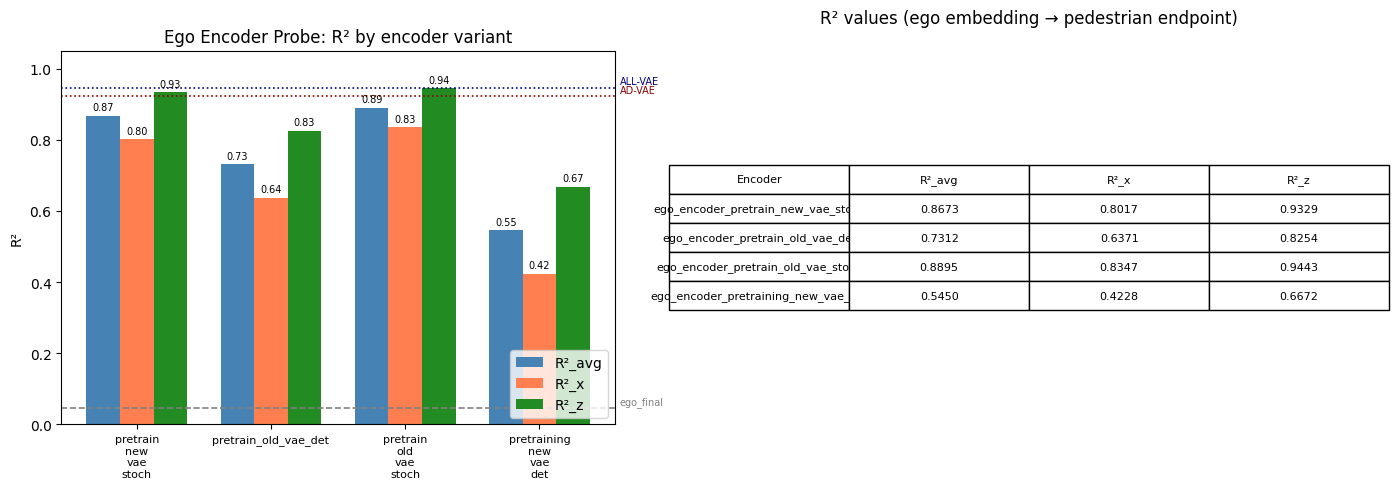

Saved: ego_probe_comparison.png


In [14]:
# ── Encode ego trajectories with each encoder and run regressions ─
ego_results = {}   # {name: (r2_avg, r2_x, r2_z)}

@torch.no_grad()
def encode_egos(enc, samples, ego_scale, device=DEVICE):
    embs = []
    for s in tqdm(samples, desc='Ego encode', leave=False):
        ego_norm = s['ego'] / ego_scale                               # (T, 2)
        t = torch.from_numpy(ego_norm).float().unsqueeze(0).to(device)
        emb = enc(t)                                                   # (1, 1, 256)
        embs.append(emb.squeeze().cpu().numpy())                       # (256,)
    return np.stack(embs)  # (N, 256)

for name, enc in ego_encoders.items():
    print(f'\n=== Ego probe: {name} ===')
    embs = encode_egos(enc, samples, EGO_SCALE)
    r2a, r2x, r2z = latent_regression(embs, endpoints, name)
    ego_results[name] = (r2a, r2x, r2z)

# ── Comparison plot ───────────────────────────────────────────────
if ego_results:
    names  = list(ego_results.keys())
    # Shorten folder names for axis labels
    def _short(n):
        n = n.replace('ego_encoder_', '').replace('_ego_encoder', '')
        parts = n.split('_')
        return '\n'.join(parts) if len(n) > 20 else n
    labels = [_short(n) for n in names]

    r2_avgs = [ego_results[n][0] for n in names]
    r2_xs   = [ego_results[n][1] for n in names]
    r2_zs   = [ego_results[n][2] for n in names]

    x = np.arange(len(names))
    w = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: grouped bar chart ──
    ax = axes[0]
    b1 = ax.bar(x - w, r2_avgs, w, label='R²_avg', color='steelblue')
    b2 = ax.bar(x,     r2_xs,   w, label='R²_x',   color='coral')
    b3 = ax.bar(x + w, r2_zs,   w, label='R²_z',   color='forestgreen')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('R²')
    ax.set_title('Ego Encoder Probe: R² by encoder variant')
    ax.legend(loc='lower right')

    # Reference lines: baseline and VAE ceilings
    ax.axhline(r2_l0,     ls='--', color='gray',    lw=1.2, label='ego_final R²')
    ax.axhline(r2_all_avg, ls=':',  color='navy',   lw=1.2)
    ax.axhline(r2_ad_avg,  ls=':',  color='darkred', lw=1.2)
    ax.text(len(names) - 0.4, r2_l0     + 0.01, 'ego_final', fontsize=7, color='gray')
    ax.text(len(names) - 0.4, r2_all_avg + 0.01, 'ALL-VAE',  fontsize=7, color='navy')
    ax.text(len(names) - 0.4, r2_ad_avg  + 0.01, 'AD-VAE',   fontsize=7, color='darkred')

    # Value labels on bars
    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    # ── Right: table ──
    ax2 = axes[1]
    ax2.axis('off')
    col_labels = ['Encoder', 'R²_avg', 'R²_x', 'R²_z']
    cell_data  = [[n, f'{r[0]:.4f}', f'{r[1]:.4f}', f'{r[2]:.4f}']
                  for n, r in ego_results.items()]
    tbl = ax2.table(cellText=cell_data, colLabels=col_labels,
                    loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.3, 1.8)
    ax2.set_title('R² values (ego embedding → pedestrian endpoint)', pad=20)

    plt.tight_layout()
    fig.savefig('ego_probe_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ego_probe_comparison.png')
else:
    print('[SKIP] No ego encoders loaded.')


In [15]:
# ── Final R² summary table ────────────────────────────────────────
import math

W = 72
print('=' * W)
print('SUMMARY R2 TABLE:  Signal  →  Pedestrian Endpoint Prediction')
print('=' * W)
print(f'{"Signal":<42} {"R2_avg":>7}  {"R2_x":>7}  {"R2_z":>7}')
print('-' * W)
print(f'{"Ego final position (2D)":<42} {r2_l0:>7.4f}  {r2_l0_x:>7.4f}  {r2_l0_z:>7.4f}')
for name, (r2a, r2x, r2z) in ego_results.items():
    label = f'Ego enc: {name}'
    if len(label) > 42:
        label = label[:41] + '…'
    print(f'{label:<42} {r2a:>7.4f}  {r2x:>7.4f}  {r2z:>7.4f}')
print(f'{"ALL-data VAE latent (256D)":<42} {r2_all_avg:>7.4f}  {r2_all_x:>7.4f}  {r2_all_z:>7.4f}')
print(f'{"AD-only VAE latent (256D)":<42} {r2_ad_avg:>7.4f}  {r2_ad_x:>7.4f}  {r2_ad_z:>7.4f}')
print('=' * W)
print()
print('Reference lines in bar chart:')
print(f'  ego_final (--gray):   {r2_l0:.4f}   ← lower bound (raw 2D input)')
print(f'  ALL-VAE   (:navy):    {r2_all_avg:.4f}   \\')
print(f'  AD-VAE    (:darkred): {r2_ad_avg:.4f}   /  upper bounds (full latent space)')


SUMMARY R2 TABLE:  Signal  →  Pedestrian Endpoint Prediction
Signal                                      R2_avg     R2_x     R2_z
------------------------------------------------------------------------
Ego final position (2D)                     0.0462   0.0013   0.0911
Ego enc: ego_encoder_pretrain_new_vae_sto…  0.8673   0.8017   0.9329
Ego enc: ego_encoder_pretrain_old_vae_det   0.7312   0.6371   0.8254
Ego enc: ego_encoder_pretrain_old_vae_sto…  0.8895   0.8347   0.9443
Ego enc: ego_encoder_pretraining_new_vae_…  0.5450   0.4228   0.6672
ALL-data VAE latent (256D)                  0.9464   0.9190   0.9738
AD-only VAE latent (256D)                   0.9216   0.8881   0.9551

Reference lines in bar chart:
  ego_final (--gray):   0.0462   ← lower bound (raw 2D input)
  ALL-VAE   (:navy):    0.9464   \
  AD-VAE    (:darkred): 0.9216   /  upper bounds (full latent space)
